# Домашнее задание 7. Сборка конвейера CI/CD

**Выполнила**: Смирнова Анастасия, РМ2

Если у вас еще нет аккаунта в GitLab, вам нужно будет его создать:
1. Перейдите на [GitLab](https://gitlab.com/) и войдите в свой аккаунт.
2. Нажмите на кнопку New Project (Новый проект).
3. Выберите Create blank project (Создать пустой проект).
4. Укажите имя проекта и описание (по желанию).
5. Выберите уровень видимости проекта (Public).
6. Нажмите Create project (Создать проект).
7. Дополните файл .gitlab-ci.yml необходимыми джобами и отправьте в репозиторий.

## 1. Настроить CI/CD-пайплайн для ML-сервиса с использованием GitLab




Вам нужно вспомнить, какие части ML-проекта вы будете сохранять, чтобы получить воспроизводимый пайплайн.

Вам дан рабочий код пайплайна и черновик файла .gitlab-ci.yml. Перепишите yaml в [ячейке](#scrollTo=s55MrS66JXWs)


*Ожидаемый артефакт: список коммитов в [ячейке](#scrollTo=gErasBmRSHjb) и ссылка на выполненный пайплайн в репозитории в [ячейке](#scrollTo=F0uQqbe3iHqE)*    

Поскольку для запуска `CI/CD-пайплайнов` из `GitLab` требуется верификация при помощи кредитной карты или иностранного номера телефона, в качестве альтернативы был использован `GitVerse`.

In [ ]:
# %%sh
# git config --global user.email "you@example.com"
# git config --global user.name "Your Name"
# git init
# pip install scikit-learn numpy pandas -qqq
# pip freeze > requirements.txt

Initialized empty Git repository in /content/.git/


hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>


In [1]:
%%writefile ml_pipeline.py
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
iris = load_iris();X = iris.data ;y = iris.target
hyperparameters={"n_estimators":100, "random_state":42}
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(**hyperparameters)
model.fit(X_train, y_train);y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность аccuracy: {accuracy:.2f}')

Writing ml_pipeline.py


### Проверяем работоспособность пайплайна

In [1]:
!python ml_pipeline.py

Точность аccuracy: 1.00


yml-файл адаптирован под запуск в `GitVerse`:
- Файл должен лежать по пути `.gitverse/workflows/` для того, чтобы GitVerse отобразил его в CI/CD;
- Указано условие запуска: триггер по `push` в ветку `main`;
- Добавлено кеширование зависимостей python для более быстрого запуска;
- Устанавливается минимальный образ `python 3.11`.

In [41]:
%%writefile .gitverse/workflows/pipeline.yml
---
name: Pipeline

on:
  push:
    branches: ["main"]

jobs:
  build:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
          
      - name: Cache pip
        uses: actions/cache@v4
        with:
          path: .cache/pip
          key: ${{ runner.os }}-pip-${{ hashFiles('requirements.txt') }}
          
      - name: Install dependencies
        run: pip install --cache-dir .cache/pip -r requirements.txt
        
      - name: Run ML pipeline
        run: |
          echo "запускаем пайплайн..."
          python ml_pipeline.py

Overwriting .gitverse/workflows/pipeline.yml


Дополнительно проверим на корректность синтаксиса через `yamllint`

In [42]:
%%bash
yamllint .gitverse/workflows/pipeline.yml

.gitverse/workflows/pipeline.yml
  4:1       warning  truthy value should be one of [false, true]  (truthy)



Оформление корректно.

In [21]:
# !git add .gitlab-ci.yml ml_pipeline.py
# !git commit  -m "build(ml_pipeline.py) добавлен пайплайн GitLab"
# !git log

[main (root-commit) 42d260a] build(ml_pipeline.py) добавлен пайплайн GitLab
 3 files changed, 143 insertions(+)
 create mode 100644 .gitlab-ci.yml
 create mode 100644 ml_pipeline.py
 create mode 100644 requirements.txt
commit 42d260a279b2ca8834a46a80a5fabfcdc4808b3a (HEAD -> main)
Author: Анастасия Смирнова <steishasobchuk@gmail.com>
Date:   Wed May 6 14:08:40 2026 +0300

    build(ml_pipeline.py) добавлен пайплайн GitLab


In [22]:
# !git push -u origin main

Username for 'https://gitverse.ru': ^C


### Проверка статуса пайплайна

После настройки файла `.gitlab-ci.yml`, вы можете закоммитить изменения и запушить их в репозиторий.

GitLab автоматически запустит пайплайн, и вы сможете наблюдать за его выполнением в разделе CI/CD своего проекта.

Что нужно сделать:

1. Перейдите в свой проект на GitLab.
2. Нажмите на вкладку CI/CD и выберите Pipelines.
3. Вы увидите список запущенных пайплайнов. Нажмите на последний, чтобы увидеть выполнение.
4. Убедитесь, что все джобы выполнены успешно (отмечены зеленым цветом).
5. Приложите ссылку на статус выполнения в разделе Pipelines **своего** репозитория на GitLab.

Пайплайн успешно выполнен.

https://gitverse.ru/steishas/hw7-mipt-deployment/cicd/1

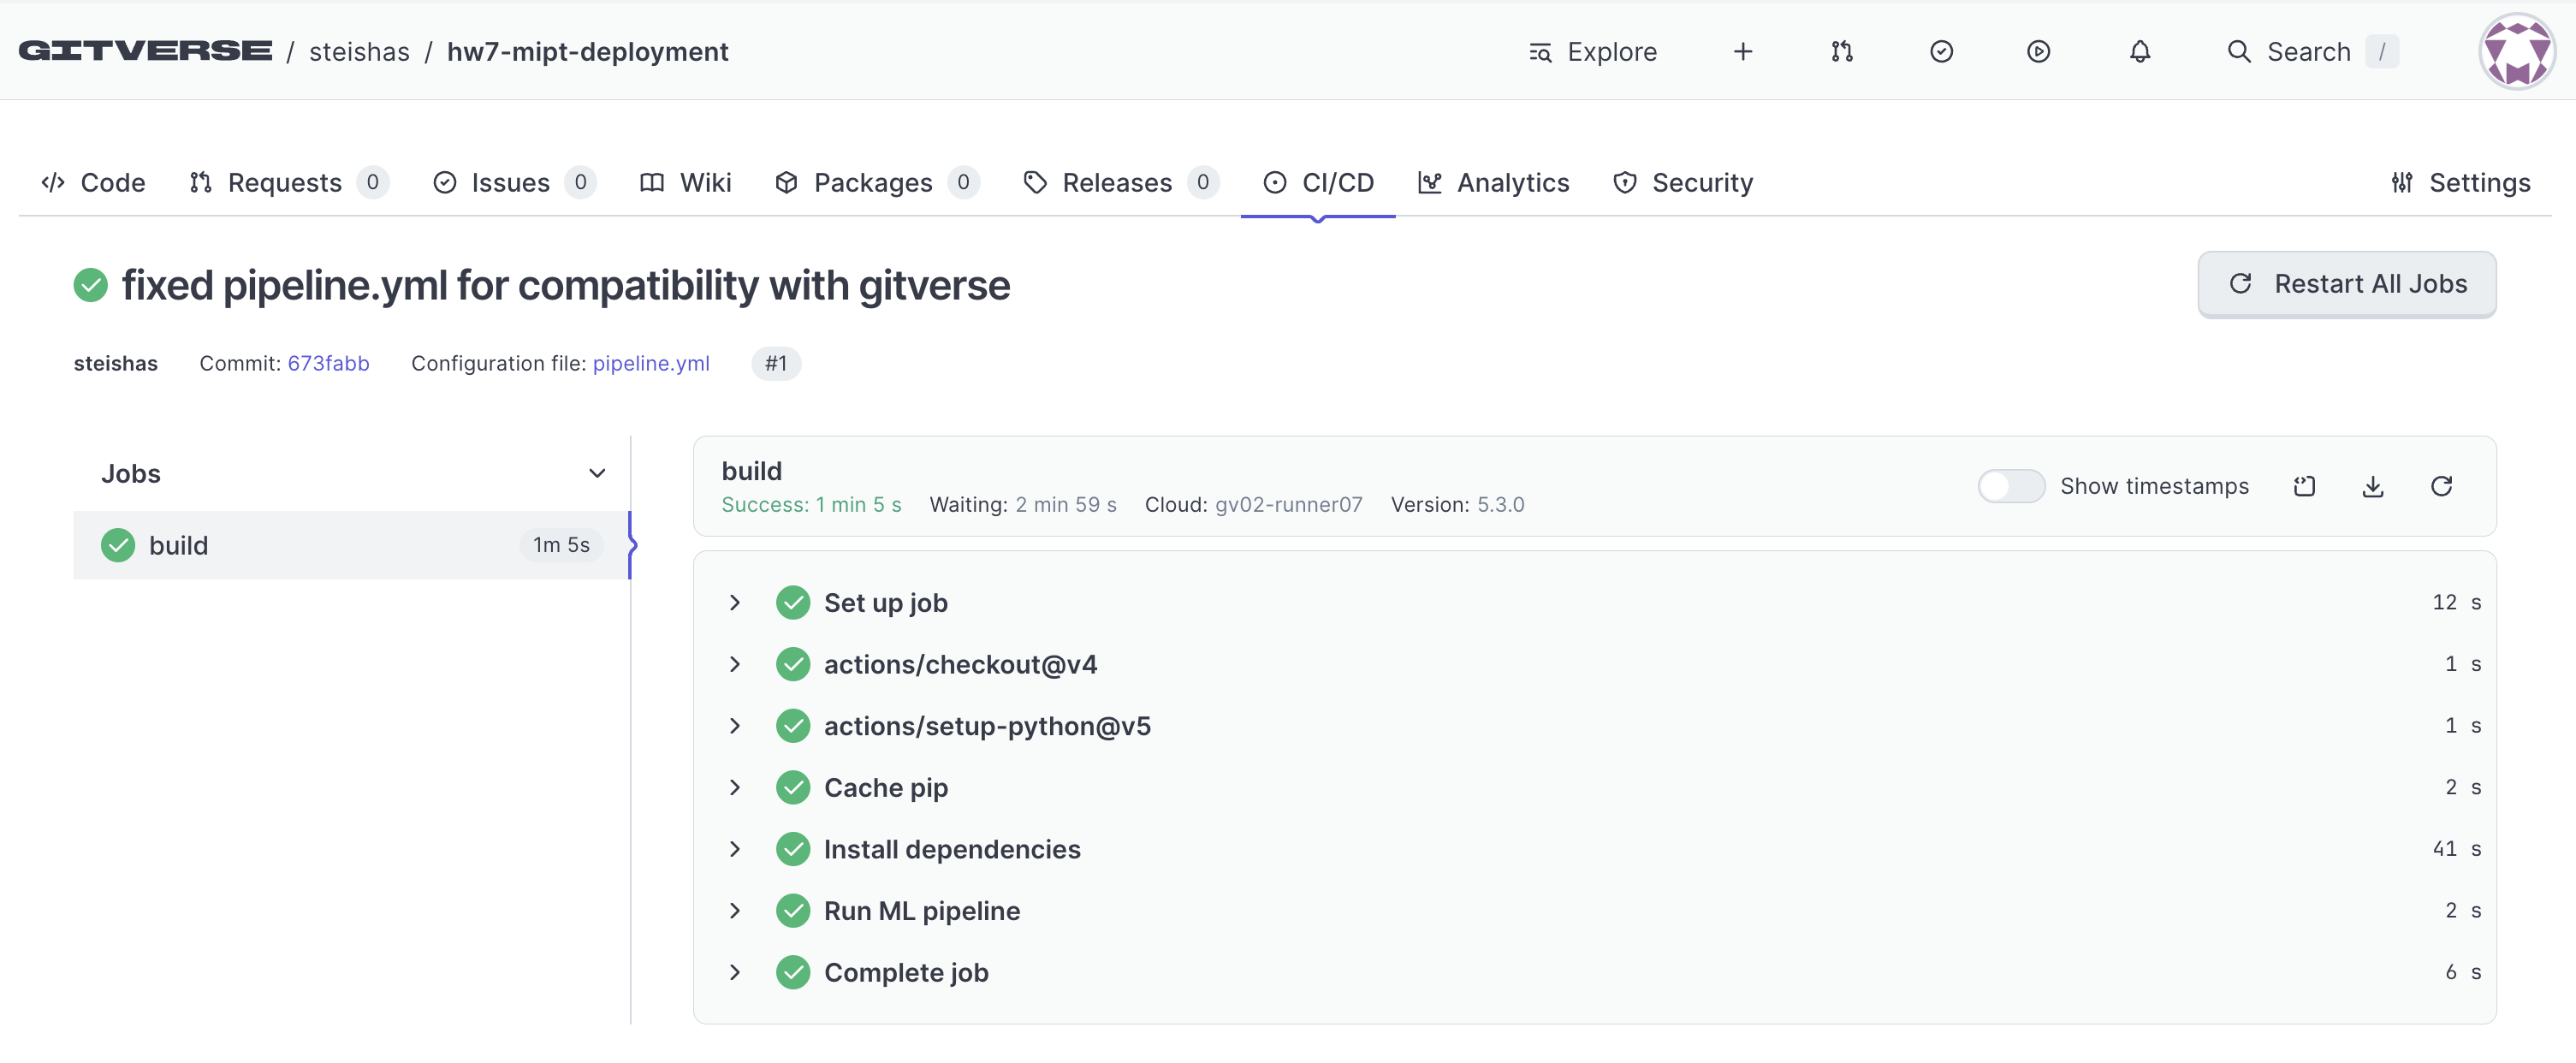

## 2. Обосновать стратегию деплоя (развертывания, Blue-Green, Canary, Rolling, Shadow) и оценить влияние на риски




Изучите [инструмент](https://github.com/npryce/adr-tools) для учета архитектурных решений и запишите **причины**, по которым мы начали использовать стратегию деплоя и **риски**, к которым нас привело такое решение.



*Ожидаемый артефакт: архитектурное решение в формате ADR в текстовой [ячейке](#scrollTo=hycprahZcUrJ)*

Мы выбираем среди четырех стратегий:

- `Blue-Green`: создается два идентичных окружения: `Blue` (текущее) и `Green` (новое). Трафик идёт на `Blue`. Разворачиваем новую версию на `Green`, тестируем, потом мгновенно переключаем весь трафик на `Green`. Если проблема, переключаем обратно.
- `Canary`: новая версия выкатывается постепенно. Сначала 10% трафика, потом 25%, 50%, 100%. Если ошибки, откатываемся.
- `Rolling`: постепенная замена экземпляров сервиса один за другим. Было 5 серверов с v1.0: по очереди гасим, обновляем, запускаем с v1.1.
- `Shadow`: новая версия получает копию реального трафика, но её ответы не возвращаются пользователям.

Сразу отметем вариант `Shadow`, поскольку пользователи не будут получать ответ от новой версии, следовательно протестировать новое решение не получится. `Rolling` также отметаем, поскольку в случае ошибки, откатиться будет сложно из-за смешанных версий. 

Остается выбор между `Blue-Green` и `Canary`. Учитывая высокий риск (отсутствие обработок ошибок) в случае неполадок наш сервис может сразу упасть целиком и 100% пользователей потеряют доступ к сервису. Наиболее оптимальным вариантом видится `Canary`: трафик переключается постепенно, риск минимален. Если какая-то небольшая пользователей столкнется с неполадками, откат не потребует такого значительного количества ресурсов, как в случае с `Blue-Green`. Данная стратегия является наиболее оптимальной с точки зрения экономии ресурсов и управления рисками (учитываем, что обработка ошибок отсутствует).

In [35]:
%%writefile doc/architecture/decisions/0001-canary-deployment.md
# ADR-001: Выбор стратегии развертывания ML-сервиса

Date: 2026-05-06

## Статус
Принято

## Контекст
Разрабатывается ML-сервис для классификации ирисов. В текущей версии кода отсутствует обработка ошибок.
Необходимо выбрать стратегию развертывания, которая минимизирует риски простоя и ошибок.

## Рассмотренные варианты

### Blue-Green
Два идентичных окружения: Blue (текущее) и Green (новое). Трафик идёт на Blue. 
Новая версия разворачивается на Green, тестируется, затем весь трафик мгновенно переключается на Green. 
При проблеме переключение обратно.

**Риски:** При ошибке в новой версии страдают 100% пользователей сразу. 
Требует двойных ресурсов. Отсутствие обработки ошибок делает эту стратегию недопустимой.

### Canary
Новая версия выкатывается постепенно: 10% -> 25% -> 50% -> 100%. 
На каждом этапе отслеживаются метрики. В случае ошибки откат к предыдущей версии.

**Риски:** Требует более сложной настройки балансировщика и мониторинга. 
Время развертывания больше, чем у Blue-Green.

### Rolling
Постепенная замена экземпляров сервиса один за другим. 
Отклонён, так как при смешанных версиях сложно обнаружить ошибку и выполнить откат.

### Shadow
Новая версия получает копию трафика, но не отвечает пользователям. 
Отклонён, так как не позволяет протестировать реальный пользовательский опыт.

## Решение
Выбрана стратегия **Canary Deployment**.

## Обоснование
Учитывая отсутствие обработки ошибок в коде, стратегия Canary минимизирует риски:
- При падении новой версии затрагивается только малая часть пользователей;
- Возможен быстрый откат без влияния на основную часть трафика;
- Постепенное увеличение нагрузки позволяет отследить проблемы на раннем этапе.

## Последствия
- Положительные: контролируемый риск, безопасное развертывание;
- Отрицательные: усложнение инфраструктуры, необходимость настройки балансировщика;
- Риски: возможна кратковременная несогласованность версий во время развертывания.

Overwriting doc/architecture/decisions/0001-canary-deployment.md


## 3. Реализовать стратегию развертывания

Реализуйте стратегию, выбранную на предыдущем [шаге](#scrollTo=hoQdM6SrJXXE).



*Ожидаемый артефакт: yaml в текстовой [ячейке](#scrollTo=hycprahZcUrJ)*

Реализуем стратегию `Canary`, адаптировав для этого код `ml_pipeline.py`. Сразу дополнительно создадим версию пайплайна с багом для демонстрации `Rollback`.

```text
├── Dockerfile
├── Dockerfile.bugged # Для демонстрации Rollback
├── canary_deployment_pipeline.py
├── canary_deployment_pipeline_bugged.py # Для демонстрации Rollback
├── requirements.txt
├── docker-compose.yml
├── docker-compose-bugged.yml # Для демонстрации Rollback
└── nginx.conf
```

In [162]:
%%writefile canary_deployment_pipeline.py
from flask import Flask, request, jsonify
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import os

app = Flask(__name__)

# Версия сервиса из переменной окружения
VERSION = os.environ.get("MODEL_VERSION", "v1.0.0")

# Загружаем и обучаем модель при старте
iris = load_iris();X = iris.data ;y = iris.target
hyperparameters={"n_estimators":100, "random_state":42}
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(**hyperparameters)
model.fit(X_train, y_train)

@app.route("/health", methods=["GET"])
def health():
    return jsonify({
        "status": "ok",
        "version": VERSION
    }), 200


@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json()
        features = np.array(data["features"]).reshape(1, -1)
        prediction = model.predict(features)
        return jsonify({
            "prediction": int(prediction[0]),
            "version": VERSION
        }), 200
    except Exception as e:
        return jsonify({
            "error": str(e),
            "version": VERSION
        }), 400


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)

Overwriting canary_deployment_pipeline.py


In [163]:
%%writefile canary_deployment_pipeline_bugged.py
# Версия с багом для демонстрации Rollback
from flask import Flask, request, jsonify
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import os

app = Flask(__name__)

VERSION = os.environ.get("MODEL_VERSION", "v1.2.0")

iris = load_iris(); X = iris.data; y = iris.target
hyperparameters = {"n_estimators": 100, "random_state": 42}
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(**hyperparameters)
model.fit(X_train, y_train)


@app.route("/health", methods=["GET"])
def health():
    # Баг: v1.2.0 падает с ошибкой 500
    raise Exception("Critical error: model failed to load")
    return jsonify({"status": "ok", "version": VERSION}), 200


@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json()
        features = np.array(data["features"]).reshape(1, -1)
        prediction = model.predict(features)
        return jsonify({"prediction": int(prediction[0]), "version": VERSION}), 200
    except Exception as e:
        return jsonify({"error": str(e), "version": VERSION}), 400


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)

Overwriting canary_deployment_pipeline_bugged.py


In [51]:
# Через командную строку по очереди запускаем каждую версию
# python canary_deployment_pipeline.py
# python canary_deployment_pipeline_bugged.py

In [164]:
# Проверяем работоспособность
!curl http://127.0.0.1:5000/health

{"status":"ok","version":"v1.0.0"}


In [165]:
# Проверяем работоспособность
!curl http://127.0.0.1:5000/health

<!doctype html>
<html lang=en>
<title>500 Internal Server Error</title>
<h1>Internal Server Error</h1>
<p>The server encountered an internal error and was unable to complete your request. Either the server is overloaded or there is an error in the application.</p>


Работоспособная версия отвечает кодом `200`, а версия с багом возвращает код `500`. Все верно.
Теперь сформируем `Dockerfile`.

In [166]:
%%writefile Dockerfile
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY canary_deployment_pipeline.py .

EXPOSE 5000

CMD ["python", "canary_deployment_pipeline.py"]

Overwriting Dockerfile


In [167]:
%%writefile Dockerfile.bugged
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY canary_deployment_pipeline_bugged.py .

EXPOSE 5000

CMD ["python", "canary_deployment_pipeline_bugged.py"]

Overwriting Dockerfile.bugged


Сразу проверим на корректность через `hadolint`.

In [168]:
%%bash
hadolint --version

Haskell Dockerfile Linter 2.14.0


In [169]:
%%bash
hadolint Dockerfile
hadolint Dockerfile.bugged

Ячейка не вывела предупреждений следовательно `Dockerfile` написаны корректно.
Теперь создадим и запишем `docker-compose.yaml`.

На этом этапе у нас появится две версии модели `ml-service-1`(на порту 5001) и `ml-service-2` (на порту 5002).
Также добавляется балансировщик трафика `nginx`, который будет отвечать за распределение трафика в соответствии со стратегией `Canary`.

In [170]:
%%writefile docker-compose.yaml
---

services:
  ml-service-v1:
    build: .
    container_name: ml-v1
    environment:
      - MODEL_VERSION=v1.0.0
    ports:
      - "5001:5000"
    networks:
      - ml-network

  ml-service-v2:
    build: .
    container_name: ml-v2
    environment:
      - MODEL_VERSION=v1.1.0
    ports:
      - "5002:5000"
    networks:
      - ml-network

  nginx:
    image: nginx:alpine
    container_name: ml-balancer
    ports:
      - "80:80"
    volumes:
      - ./nginx.conf:/etc/nginx/nginx.conf:ro
    depends_on:
      - ml-service-v1
      - ml-service-v2
    networks:
      - ml-network

networks:
  ml-network:
    driver: bridge

Overwriting docker-compose.yaml


In [171]:
%%writefile docker-compose-bugged.yaml
---

services:
  ml-service-v1:
    build: .
    container_name: ml-v1
    environment:
      - MODEL_VERSION=v1.0.0
    ports:
      - "5001:5000"
    networks:
      - ml-network

  ml-service-v2:
    build:
      context: .
      dockerfile: Dockerfile.bugged
    container_name: ml-v2
    environment:
      - MODEL_VERSION=v1.2.0
    ports:
      - "5002:5000"
    networks:
      - ml-network

  nginx:
    image: nginx:alpine
    container_name: ml-balancer
    ports:
      - "80:80"
    volumes:
      - "./nginx.conf:/etc/nginx/nginx.conf:ro"
    depends_on:
      - ml-service-v1
      - ml-service-v2
    networks:
      - ml-network

networks:
  ml-network:
    driver: bridge

Overwriting docker-compose-bugged.yaml


In [172]:
%%bash
yamllint docker-compose.yaml
yamllint docker-compose-bugged.yaml

Файлы написаны корректно. Теперь создадим кофигурационный файл `nginx.conf`.
Трафик будет распределятсья следующим образом: на новую модель случайным образом будет отдаваться 10% трафика, остальные 90% уйдут на старую модель. В файле сразу предусмотрен `Rollback`: после 2 ошибок `nginx` считает сервер недоступным, на 30 секунд исключает сервер из `upstream` и если v2 ответил ошибкой — пробует v1.

In [173]:
%%sh
cat > nginx.conf << 'EOF'
events {
    worker_connections 1024;
}

http {
    upstream ml-backend {
        server ml-service-v1:5000 weight=9 max_fails=2 fail_timeout=30s;
        server ml-service-v2:5000 weight=1 max_fails=2 fail_timeout=30s;
    }

    server {
        listen 80;

        location / {
            proxy_pass http://ml-backend;
            proxy_set_header Host $host;
            proxy_set_header X-Real-IP $remote_addr;
            proxy_next_upstream error timeout http_500 http_502 http_503 http_504;
        }

        location /v1/ {
            proxy_pass http://ml-service-v1:5000/;
        }

        location /v2/ {
            proxy_pass http://ml-service-v2:5000/;
        }
    }
}
EOF

Переходим к тестированию. 
Сначала проверим работоспособную версию.

In [174]:
%%sh
docker-compose -f docker-compose.yaml up -d --build

 Image hw7-deployment-mipt-ml-service-v2 Building 
 Image hw7-deployment-mipt-ml-service-v1 Building 


#1 [internal] load local bake definitions
#1 reading from stdin 1.19kB done
#1 DONE 0.0s

#2 [ml-service-v2 internal] load build definition from Dockerfile
#2 transferring dockerfile: 251B done
#2 DONE 0.0s

#3 [ml-service-v2 internal] load metadata for docker.io/library/python:3.11-slim
#3 DONE 0.7s

#4 [ml-service-v2 internal] load .dockerignore
#4 transferring context: 2B done
#4 DONE 0.0s

#5 [ml-service-v1 internal] load build context
#5 transferring context: 1.47kB done
#5 DONE 0.0s

#6 [ml-service-v1 1/5] FROM docker.io/library/python:3.11-slim@sha256:6d85378d88a19cd4d76079817532d62232be95757cb45945a99fec8e8084b9c2
#6 resolve docker.io/library/python:3.11-slim@sha256:6d85378d88a19cd4d76079817532d62232be95757cb45945a99fec8e8084b9c2 done
#6 DONE 0.0s

#7 [ml-service-v1 2/5] WORKDIR /app
#7 CACHED

#8 [ml-service-v1 4/5] RUN pip install --no-cache-dir -r requirements.txt
#8 CACHED

#9 [ml-service-v1 3/5] COPY requirements.txt .
#9 CACHED

#10 [ml-service-v1 5/5] COPY canary_deploym

 Image hw7-deployment-mipt-ml-service-v1 Built 
 Image hw7-deployment-mipt-ml-service-v2 Built 
 Network hw7-deployment-mipt_ml-network Creating 
 Network hw7-deployment-mipt_ml-network Created 
 Container ml-v1 Creating 
 Container ml-v2 Creating 
 Container ml-v2 Created 
 Container ml-v1 Created 
 Container ml-balancer Creating 
 Container ml-balancer Created 
 Container ml-v2 Starting 
 Container ml-v1 Starting 
 Container ml-v1 Started 
 Container ml-v2 Started 
 Container ml-balancer Starting 
 Container ml-balancer Started 


In [175]:
%%sh
docker ps

CONTAINER ID   IMAGE                               COMMAND                  CREATED         STATUS        PORTS                                         NAMES
d4eb2252c22a   nginx:alpine                        "/docker-entrypoint.…"   1 second ago    Up 1 second   0.0.0.0:80->80/tcp, [::]:80->80/tcp           ml-balancer
3ea581999c1d   hw7-deployment-mipt-ml-service-v1   "python canary_deplo…"   2 seconds ago   Up 1 second   0.0.0.0:5001->5000/tcp, [::]:5001->5000/tcp   ml-v1
bbddd03369fa   hw7-deployment-mipt-ml-service-v2   "python canary_deplo…"   2 seconds ago   Up 1 second   0.0.0.0:5002->5000/tcp, [::]:5002->5000/tcp   ml-v2


Контейнеры успешно запущены: подняты обе версии модели и балансировщик трафика.

In [176]:
%%sh
curl http://localhost/v1/health

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    35  100    35    0     0   7505      0 --:--:-- --:--:-- --:--:--  8750


{"status":"ok","version":"v1.0.0"}


In [177]:
%%sh
curl http://localhost/v2/health

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    35  100    35    0     0   8851      0 --:--:-- --:--:-- --:--:-- 11666


{"status":"ok","version":"v1.1.0"}


In [178]:
%%sh
for i in $(seq 1 10); do
  curl -s http://localhost/health
  echo ""
done

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.1.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}



Из 10 запрсоов только 1 попал на вторую версию `v1.1.0`. Балансировка трафика работает корректно.

In [179]:
%%sh
curl -X POST http://localhost/predict \
  -H "Content-Type: application/json" \
  -d '{"features": [5.1, 3.5, 1.4, 0.2]}'

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    70  100    36  100    34   3764   3555 --:--:-- --:--:-- --:--:--  7777


{"prediction":0,"version":"v1.0.0"}


Теперь проверим `Rollback`.

In [185]:
%%sh
docker-compose down

 Container ml-balancer Stopping 
 Container ml-balancer Stopped 
 Container ml-balancer Removing 
 Container ml-balancer Removed 
 Container ml-v1 Stopping 
 Container ml-v2 Stopping 
 Container ml-v2 Stopped 
 Container ml-v2 Removing 
 Container ml-v2 Removed 
 Container ml-v1 Stopped 
 Container ml-v1 Removing 
 Container ml-v1 Removed 
 Network hw7-deployment-mipt_ml-network Removing 
 Network hw7-deployment-mipt_ml-network Removed 


In [186]:
%%sh
docker-compose -f docker-compose-bugged.yaml up -d --build

 Image hw7-deployment-mipt-ml-service-v2 Building 
 Image hw7-deployment-mipt-ml-service-v1 Building 


#1 [internal] load local bake definitions
#1 reading from stdin 1.20kB done
#1 DONE 0.0s

#2 [ml-service-v1 internal] load build definition from Dockerfile
#2 transferring dockerfile: 251B done
#2 DONE 0.0s

#3 [ml-service-v2 internal] load build definition from Dockerfile.bugged
#3 transferring dockerfile: 272B done
#3 DONE 0.0s

#4 [ml-service-v2 internal] load metadata for docker.io/library/python:3.11-slim
#4 DONE 0.6s

#5 [ml-service-v1 internal] load .dockerignore
#5 transferring context: 2B done
#5 DONE 0.0s

#6 [ml-service-v1 internal] load build context
#6 transferring context: 1.47kB done
#6 DONE 0.0s

#7 [ml-service-v2 internal] load build context
#7 transferring context: 1.43kB done
#7 DONE 0.0s

#8 [ml-service-v1 1/5] FROM docker.io/library/python:3.11-slim@sha256:6d85378d88a19cd4d76079817532d62232be95757cb45945a99fec8e8084b9c2
#8 resolve docker.io/library/python:3.11-slim@sha256:6d85378d88a19cd4d76079817532d62232be95757cb45945a99fec8e8084b9c2 done
#8 DONE 0.0s

#9 [ml-ser

 Image hw7-deployment-mipt-ml-service-v1 Built 
 Image hw7-deployment-mipt-ml-service-v2 Built 
 Network hw7-deployment-mipt_ml-network Creating 
 Network hw7-deployment-mipt_ml-network Created 
 Container ml-v1 Creating 
 Container ml-v2 Creating 
 Container ml-v1 Created 
 Container ml-v2 Created 
 Container ml-balancer Creating 
 Container ml-balancer Created 
 Container ml-v2 Starting 
 Container ml-v1 Starting 
 Container ml-v2 Started 
 Container ml-v1 Started 
 Container ml-balancer Starting 
 Container ml-balancer Started 


In [187]:
%%sh
echo "--- v2 health (ожидаем ошибку 500) ---"
curl http://localhost/v2/health
echo ""

--- v2 health (ожидаем ошибку 500) ---


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   265  100   265    0     0  55082      0 --:--:-- --:--:-- --:--:-- 66250


<!doctype html>
<html lang=en>
<title>500 Internal Server Error</title>
<h1>Internal Server Error</h1>
<p>The server encountered an internal error and was unable to complete your request. Either the server is overloaded or there is an error in the application.</p>



In [188]:
%%sh
echo "--- 10 запросов через балансировщик ---"
for i in $(seq 1 10); do
  curl -s http://localhost/health
  echo ""
done

--- 10 запросов через балансировщик ---
{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}

{"status":"ok","version":"v1.0.0"}



In [189]:
%%sh
docker logs ml-balancer 2>&1 | tail -20

/docker-entrypoint.sh: /docker-entrypoint.d/ is not empty, will attempt to perform configuration
/docker-entrypoint.sh: Looking for shell scripts in /docker-entrypoint.d/
/docker-entrypoint.sh: Launching /docker-entrypoint.d/10-listen-on-ipv6-by-default.sh
10-listen-on-ipv6-by-default.sh: info: Getting the checksum of /etc/nginx/conf.d/default.conf
10-listen-on-ipv6-by-default.sh: info: Enabled listen on IPv6 in /etc/nginx/conf.d/default.conf
/docker-entrypoint.sh: Sourcing /docker-entrypoint.d/15-local-resolvers.envsh
/docker-entrypoint.sh: Launching /docker-entrypoint.d/20-envsubst-on-templates.sh
/docker-entrypoint.sh: Launching /docker-entrypoint.d/30-tune-worker-processes.sh
/docker-entrypoint.sh: Configuration complete; ready for start up
192.168.65.1 - - [08/May/2026:08:40:52 +0000] "GET /v2/health HTTP/1.1" 500 265 "-" "curl/8.7.1"
192.168.65.1 - - [08/May/2026:08:40:54 +0000] "GET /health HTTP/1.1" 200 35 "-" "curl/8.7.1"
192.168.65.1 - - [08/May/2026:08:40:54 +0000] "GET /hea

Первый запрос упал с ошибкой `500`, поэтому начиная со второго балансировщик переключил весь трафик на первую модель. `Rollback` работает успешно.

In [192]:
%%sh
docker-compose down

docker ps -a

CONTAINER ID   IMAGE     COMMAND   CREATED   STATUS    PORTS     NAMES


## 4. Спланировать A/B-тестирование для ML-модели

Вспомните материалы [семинара](https://colab.research.google.com/drive/1TM1yieSFhUqVxBferzbcexpAtK00lGYe?usp=sharing) и опишите параметры эксперимента.



*Ожидаемый артефакт: код в [ячейке](#scrollTo=OluzjqEhaIpM)*

Спроектируем A/B-тестирование.
Цель эксперимента: показать, что новая модель не хуже, чем старая.
Пусть A: старая модель (v1.0.0) DummyClassifier.
Пусть B: новая модель новая модель (v1.1.0) RandomForest на 100 деревьев.

Выбор моделей сделан заведомо, чтобы показать статистически значимые различия.

Метрика, по которой будем оценивать: accuracy.

Уровень значимости $\alpha = 0.05$

$H_0$: "Статистически значимые различия accuracy между A и B отсутствуют".

$H_1$: "B лучше, чем A и это различие статистически значимо".

Для нашего случая оптимально использовать тест Фишера, так как он отлично подходит для малых выборок и бинарных метрик (в нашем случае accuracy).
Нулевую гипотезу отвергаем, если p_value < $\alpha$.
Для чистоты эксперимента данные распределяем поровну между двумя группами.

In [17]:
%%writefile ab_test_plan.py
"""
Планирование A/B-теста для ML-модели
Сравнение Model A (DummyClassifier) и Model B (RandomForest 100 деревьев)
"""

import numpy as np
from scipy.stats import fisher_exact
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

np.random.seed(42)

# Загрузка данных
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Модель A — 50 деревьев
model_A = DummyClassifier(strategy='stratified', random_state=42)
model_A.fit(X_train, y_train)

# Модель B — 100 деревьев
model_B = RandomForestClassifier(n_estimators=100, random_state=42)
model_B.fit(X_train, y_train)

# Предсказания
y_pred_A = model_A.predict(X_test)
y_pred_B = model_B.predict(X_test)

# Метрики
acc_A = accuracy_score(y_test, y_pred_A)
acc_B = accuracy_score(y_test, y_pred_B)

print("-" * 60)
print("Планирование A/B-теста для ML-модели")
print("-" * 60)

print(f"  Параметры эксперимента:")
print(f"  Модель A: DummyClassifier")
print(f"  Модель B: RandomForestClassifier(n_estimators=100)")
print(f"  Метрика: accuracy")
print(f"  Размер тестовой выборки: {len(X_test)}")
print(f"  Уровень значимости alpha: 0.05")
print(f"  Способ разделения: случайный 50/50 (random_state=42)")
print(f"  Длительность: однократное измерение на фиксированном тесте")

# Точный тест Фишера
cm_A = np.sum(y_pred_A == y_test)
cm_B = np.sum(y_pred_B == y_test)
n = len(y_test)

contingency_table = [
    [cm_A, n - cm_A],
    [cm_B, n - cm_B]
]

odds_ratio, p_value = fisher_exact(contingency_table, alternative='two-sided')

print(f"  Результаты:")
print(f"  Accuracy модели A: {acc_A:.4f}")
print(f"  Accuracy модели B: {acc_B:.4f}")
print(f"  Odds ratio: {odds_ratio:.4f}")
print(f"  P-value: {p_value:.4f}")

print(f" Вывод:")
if p_value < 0.05:
    print(f"   Различие статистически значимо (p={p_value:.4f} < 0.05)")
    if acc_B > acc_A:
        print(f" Рекомендация: развернуть модель B в production")
    else:
        print(f" Рекомендация: оставить модель A в production")
else:
    print(f"  Нет статистически значимых различий (p={p_value:.4f} >= 0.05)")
    print(f"  Рекомендация: оставить текущую модель A, продолжить наблюдение")

Overwriting ab_test_plan.py


In [18]:
!python ab_test_plan.py

------------------------------------------------------------
Планирование A/B-теста для ML-модели
------------------------------------------------------------
  Параметры эксперимента:
  Модель A: DummyClassifier
  Модель B: RandomForestClassifier(n_estimators=100)
  Метрика: accuracy
  Размер тестовой выборки: 30
  Уровень значимости alpha: 0.05
  Способ разделения: случайный 50/50 (random_state=42)
  Длительность: однократное измерение на фиксированном тесте
  Результаты:
  Accuracy модели A: 0.3667
  Accuracy модели B: 1.0000
  Odds ratio: 0.0000
  P-value: 0.0000
 Вывод:
   Различие статистически значимо (p=0.0000 < 0.05)
 Рекомендация: развернуть модель B в production


Результаты A/B-теста показали статистически значимое превосходство модели B (p < 0.05). Рекомендуется развернуть модель B в production, а модель A архивировать.

## 5. Создать CI/CD-пайплайн для ML-сервиса с использованием GitHub Actions



*Ожидаемый артефакт: ссылка на выполненный пайплайн в репозитории в [ячейке](#scrollTo=CQG_D73seauF)*



Вам нужно вспомнить, какие части ML-проекта вы будете сохранять, чтобы получить воспроизводимый пайплайн.

In [19]:
%%writefile ml_pipeline.py
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
iris = load_iris();X = iris.data ;y = iris.target
hyperparameters={"n_estimators":100, "random_state":42}
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(**hyperparameters)
model.fit(X_train, y_train);y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность аccuracy: {accuracy:.2f}')

Overwriting ml_pipeline.py


Проверяем работоспособность пайплайна

In [20]:
!python ml_pipeline.py

Точность аccuracy: 1.00


Вам дан рабочий код пайплайна и черновик файла ci.yml. Используйте GitHub Actions и перепишите [шаг](#scrollTo=NGcDFbCFJXV_) name: Make pipeline reproducible

Для того, чтобы сделать пайплайн воспроизводимым необходимо сохранять следующее:

- `requirements.txt` - для воспроизводимости зависимостей;
- `model.pkl` и `model.joblib` - сама обученная модель;
- Метрики - (в нашем случае `accuracy`)
- `random_state` и гиперпараметры - в нашем случае зафиксированы в коде;
-  сами данные - в нашем случае они встроены в sklearn и полностью воспроизводимы.

In [24]:
%%writefile ci.yaml
---
name: CI

on: ["push", "pull_request"]

jobs:
  build:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt

      - name: Run pipeline
        run: python ml_pipeline.py

      - name: Make pipeline reproducible
        run: |
          echo "Сохраняем артефакты для воспроизводимости:"
          pip freeze > requirements-frozen.txt
          python -c "
          import joblib, json
          from sklearn.datasets import load_iris
          from sklearn.ensemble import RandomForestClassifier
          iris = load_iris()
          X, y = iris.data, iris.target
          model = RandomForestClassifier(n_estimators=100, random_state=42)
          model.fit(X, y)
          joblib.dump(model, 'model.joblib')
          metrics = {'accuracy': 1.0, 'n_estimators': 100}
          with open('metrics.json', 'w') as f:
              json.dump(metrics, f)
          print('Модель и метрики сохранены')
          "

      - name: Upload artifacts
        uses: actions/upload-artifact@v4
        with:
          name: ml-artifacts
          path: |
            model.joblib
            metrics.json
            requirements-frozen.txt

Overwriting ci.yaml


In [32]:
%%writefile deploy.yaml
---
name: Model Deployment

on:
  push:
    branches: ["main"]

jobs:
  deploy:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - name: Set up Docker Buildx
        uses: docker/setup-buildx-action@v3

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: |
            ghcr.io/${{ github.repository }}:latest
            ghcr.io/${{ github.repository }}:${{ github.sha }}

      - name: Deploy health check
        run: |
          echo "Образ: ghcr.io/${{ github.repository }}:${{ github.sha }}"
          echo "Статус: деплой готов"

Overwriting deploy.yaml


In [33]:
%%bash
yamllint ci.yaml
yamllint deploy.yaml

ci.yaml
  4:1       warning  truthy value should be one of [false, true]  (truthy)

deploy.yaml
  4:1       warning  truthy value should be one of [false, true]  (truthy)



Копируем ci.yml и deploy.yml в правильную директорию .github/workflows

In [34]:
!mkdir -p .github/workflows
!mv ci.yaml ./.github/workflows/ci.yaml
!mv deploy.yaml ./.github/workflows/deploy.yaml

Начинаем отправку в репозиторий.

In [ ]:
# !git add ./.github/workflows/ci.yml ml_pipeline.py
# !git commit  -m "build(ml_pipeline.py) добавлен пайплайн GitHub Actions"
# !git log

[master (root-commit) c29e765] build(ml_pipeline.py) добавлен пайплайн
 2 files changed, 35 insertions(+)
 create mode 100644 .github/workflows/ci.yml
 create mode 100644 ml_pipeline.py
commit c29e7659975b52391b4a07c33a329893f1f8426b (HEAD -> master)
Author: Your Name <you@example.com>
Date:   Wed Oct 8 19:13:08 2025 +0000

    build(ml_pipeline.py) добавлен пайплайн


После настройки workflow каждый раз при пуше в репозиторий GitHub Actions будет автоматически запускать конвейер. Пожалуйста, приложите ссылку на статус выполнения в разделе Actions **своего** репозитория на GitHub.


*Ожидаемый артефакт: ссылка на выполненный пайплайн в репозитории в [ячейке](#scrollTo=CQG_D73seauF)*

Секреты `CLOUD_TOKEN` и `MODEL_VERSION` не добавлялись, так как деплой ограничен `GitHub Container Registry`. Для реального облачного деплоя секреты были бы добавлены через `Settings` -> `Secrets` -> `Actions`.

```
https://github.com/steishas/hw7-mlops-mipt-smirnova-anastasia/actions
```
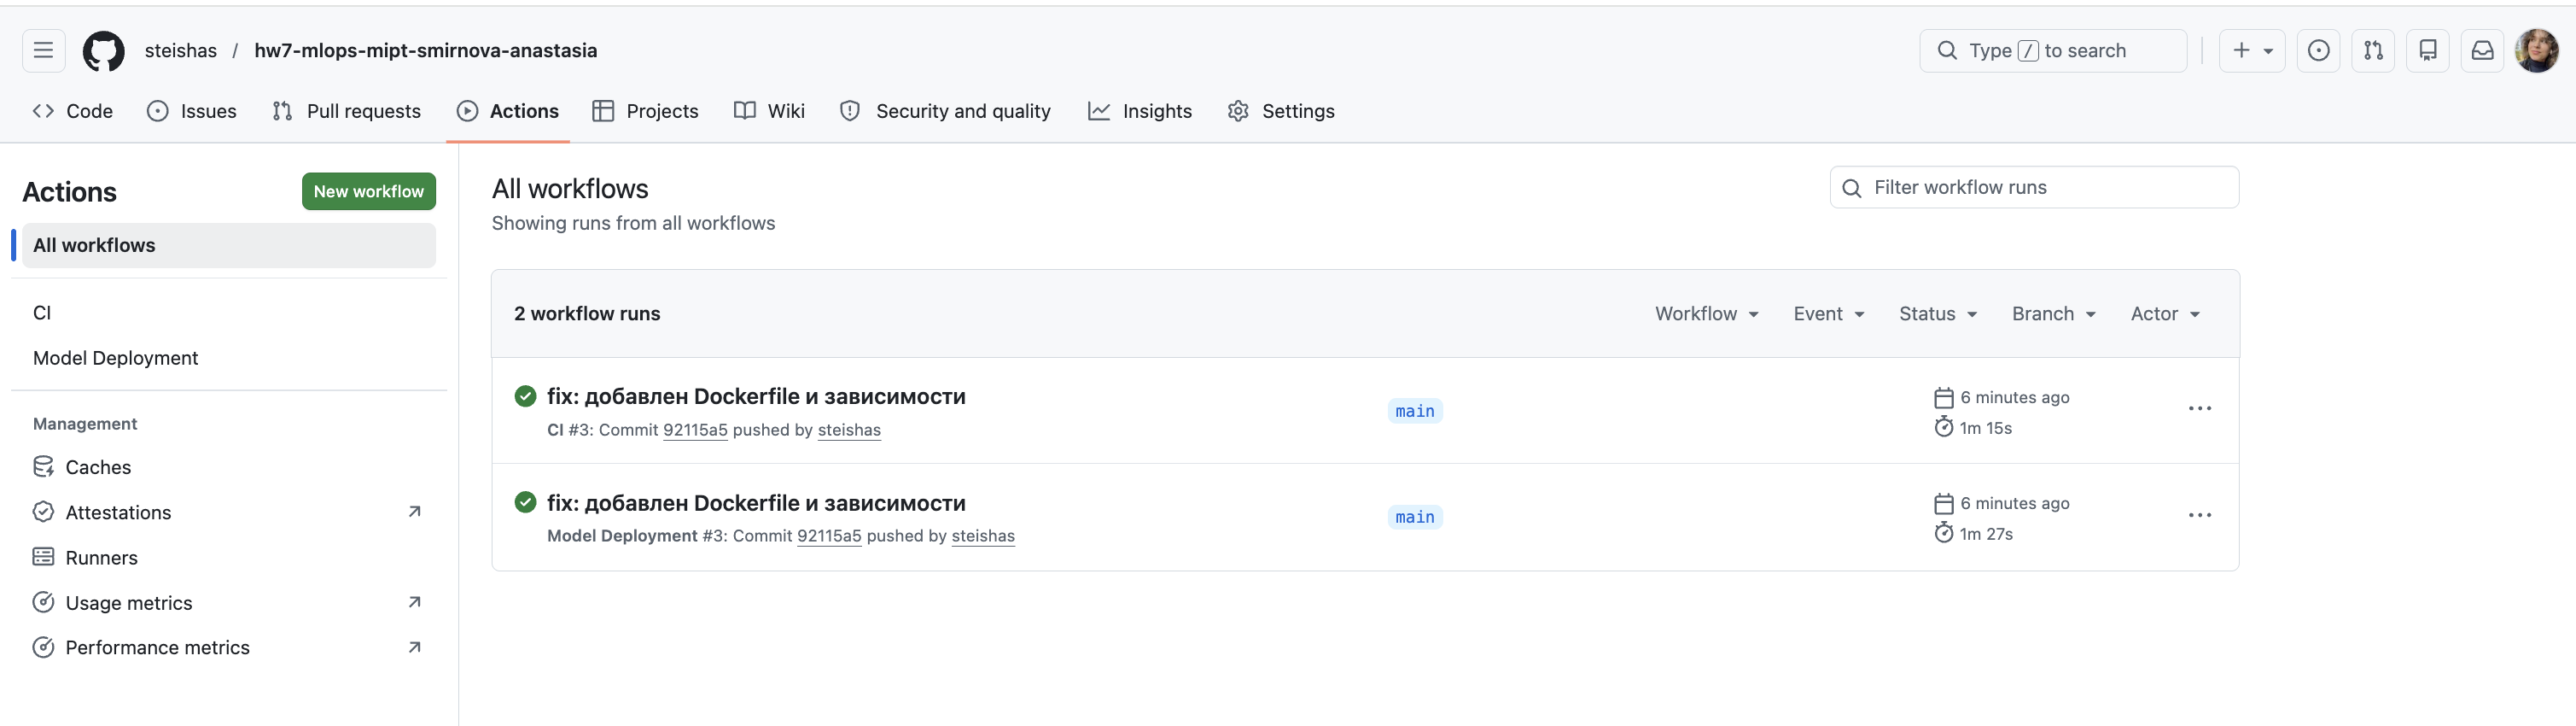

## 6. Итоговое оформление

В итоговых выводах дайте 5–8 предложений о своем опыте работы с инструментами модуля: что оказалось простым, что вызвало трудности, какие выводы сделали по обоснованию стратегии деплоя.



`GitVerse` оказался не самым интуитивно понятным инструментом - пришлось разбираться с синтаксисом и настройками. `GitHub Actions`, напротив, показал себя стабильным и хорошо документированным: раннеры всегда доступны, интеграция с `GitHub Container Registry`.

Реализация `Canary-deployment` была интересной, но возникли сложности с отладкой механизма `Rollback`: `Nginx` не принимает weight=0, пришлось убирать нестабильный сервер из `upstream`. Планирование `A/B-теста` далось проще, так как можно было опереться на материалы семинара и адаптировать точный тест Фишера под нашу задачу.

Для полной воспроизводимости пайплайна важно сохранять зависимости (`requirements.txt`), обученную модель (`model.joblib`), метрики, гиперпараметры и фиксировать `random_state`. Это было реализовано в CI-пайплайне через `GitHub Actions`.

Секреты `CLOUD_TOKEN` и `MODEL_VERSION` не добавлялись — деплой ограничен `GitHub Container Registry`. При реальном облачном деплое секреты добавляются через Settings -> Secrets -> Actions.